In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine

engine = create_engine("sqlite:///../bluestock_mf.db")

nav = pd.read_sql("SELECT * FROM fact_nav", engine)
nav["date"] = pd.to_datetime(nav["date"])

fund_master = pd.read_sql("SELECT * FROM dim_fund", engine)
transactions = pd.read_sql("SELECT * FROM fact_transactions", engine)
transactions["date"] = pd.to_datetime(transactions["date"])

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
aum["date"] = pd.to_datetime(aum["date"])

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

category_inflows = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

folio_count = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

bench = pd.read_csv("../data/raw/10_benchmark_indices.csv")
bench["date"] = pd.to_datetime(bench["date"])

print("nav:", nav.shape)
print("fund_master:", fund_master.shape)
print("transactions:", transactions.shape)
print("aum:", aum.shape)
print("sip:", sip.shape)
print("category_inflows:", category_inflows.shape)
print("folio_count:", folio_count.shape)
print("portfolio_holdings:", portfolio_holdings.shape)

nav: (46000, 3)
fund_master: (40, 7)
transactions: (32778, 10)
aum: (90, 5)
sip: (48, 6)
category_inflows: (144, 3)
folio_count: (21, 6)
portfolio_holdings: (322, 8)


In [3]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend — All 40 Schemes (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1, line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left"
)
fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="red", opacity=0.1, line_width=0,
    annotation_text="2024 Corrections", annotation_position="top left"
)

fig.update_layout(showlegend=False, height=600)
fig.write_image("../nav_trend_all_schemes.png")
fig.show()

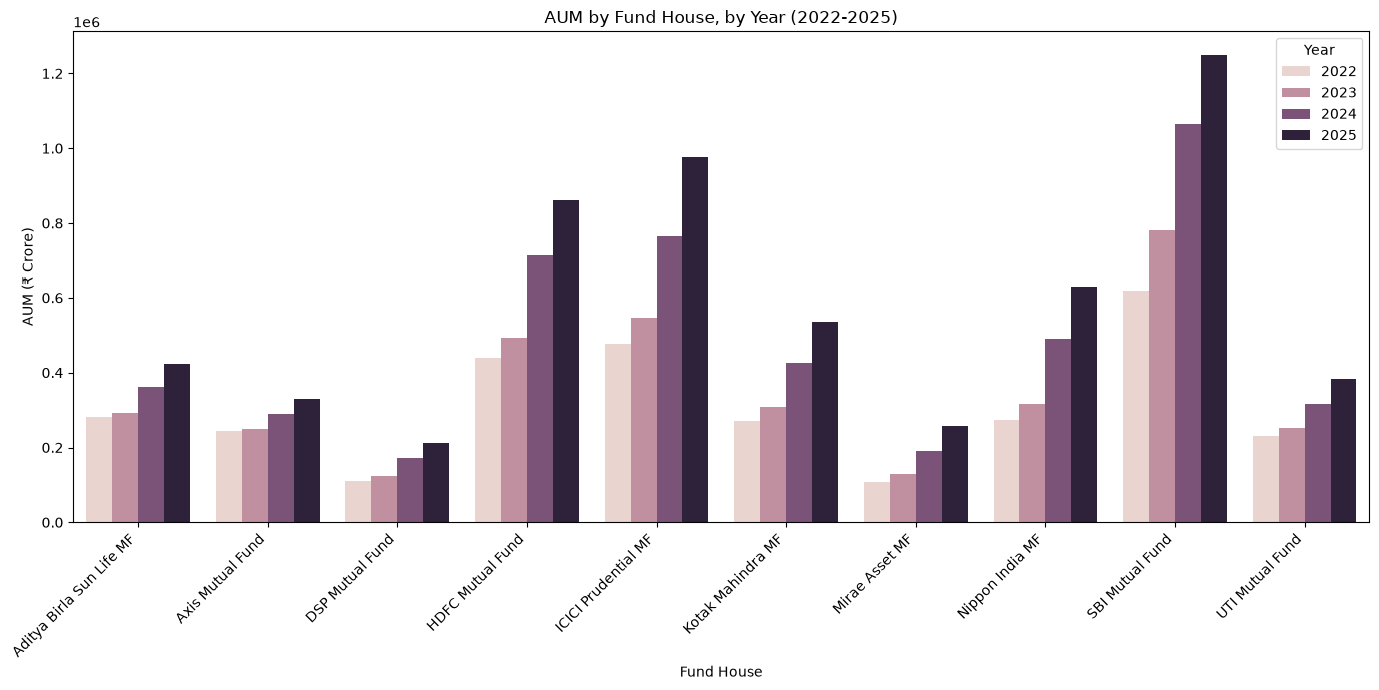

         fund_house  year     aum_crore
32  SBI Mutual Fund  2022  6.175000e+05
33  SBI Mutual Fund  2023  7.810000e+05
34  SBI Mutual Fund  2024  1.064667e+06
35  SBI Mutual Fund  2025  1.250000e+06

Top fund house by average AUM:
fund_house
SBI Mutual Fund        943444.444444
ICICI Prudential MF    699222.222222
HDFC Mutual Fund       636888.888889
Name: aum_crore, dtype: float64


In [4]:
aum["year"] = aum["date"].dt.year
aum_yearly = aum.groupby(["fund_house", "year"])["aum_crore"].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=aum_yearly, x="fund_house", y="aum_crore", hue="year")
plt.title("AUM by Fund House, by Year (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Crore)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.savefig("../aum_growth_by_fund_house.png", dpi=150)
plt.show()

# Confirm SBI's position
print(aum_yearly[aum_yearly["fund_house"] == "SBI Mutual Fund"])
print("\nTop fund house by average AUM:")
print(aum.groupby("fund_house")["aum_crore"].mean().sort_values(ascending=False).head(3))

In [5]:
sip["month"] = pd.to_datetime(sip["month"])
sip_sorted = sip.sort_values("month")

fig = px.line(
    sip_sorted,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow (₹ Crore) — Jan 2022 to Dec 2025"
)

max_row = sip_sorted.loc[sip_sorted["sip_inflow_crore"].idxmax()]
fig.add_annotation(
    x=max_row["month"], y=max_row["sip_inflow_crore"],
    text=f"All-time high: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True, arrowhead=2, ay=-40
)

fig.update_layout(height=500)
fig.write_image("../sip_inflow_trend.png")
fig.show()

print("Actual peak:", max_row["month"], "-", max_row["sip_inflow_crore"])

Actual peak: 2025-12-01 00:00:00 - 31002


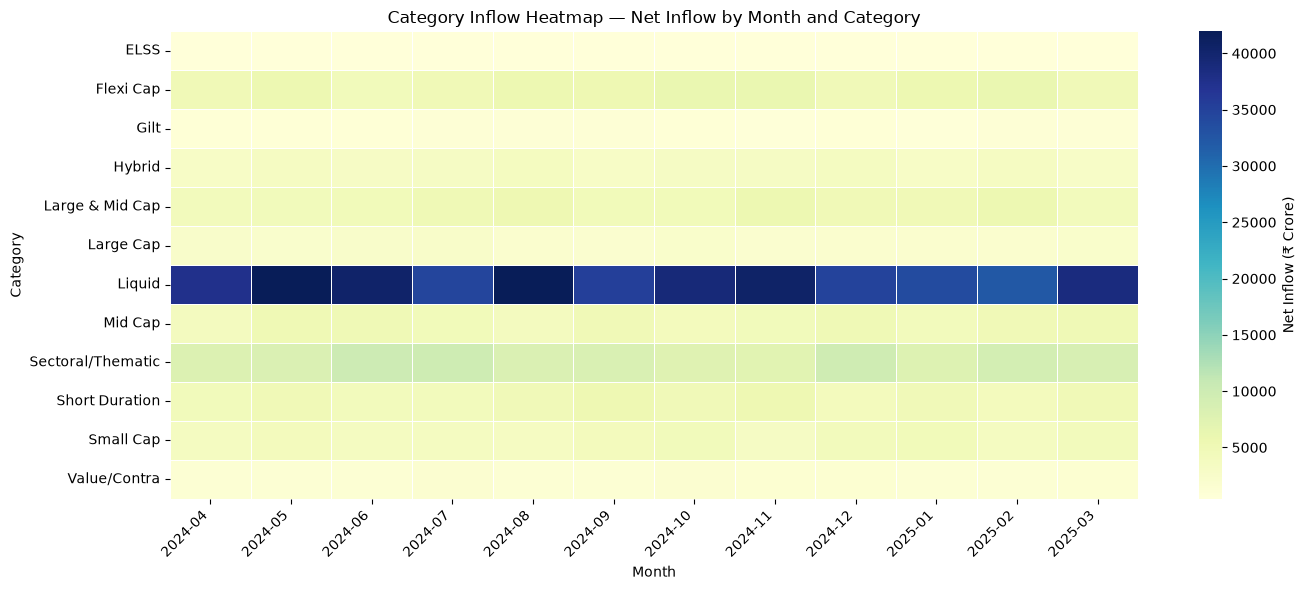

In [7]:
category_inflows["month"] = pd.to_datetime(category_inflows["month"])
category_inflows["month_str"] = category_inflows["month"].dt.strftime("%Y-%m")

pivot = category_inflows.pivot(index="category", columns="month_str", values="net_inflow_crore")

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap="YlGnBu", annot=False, linewidths=0.5, cbar_kws={"label": "Net Inflow (₹ Crore)"})
plt.title("Category Inflow Heatmap — Net Inflow by Month and Category")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../category_inflow_heatmap.png", dpi=150)
plt.show()

In [9]:
txns_full = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
txns_full["transaction_date"] = pd.to_datetime(txns_full["transaction_date"])
print(txns_full.shape)

(32778, 13)


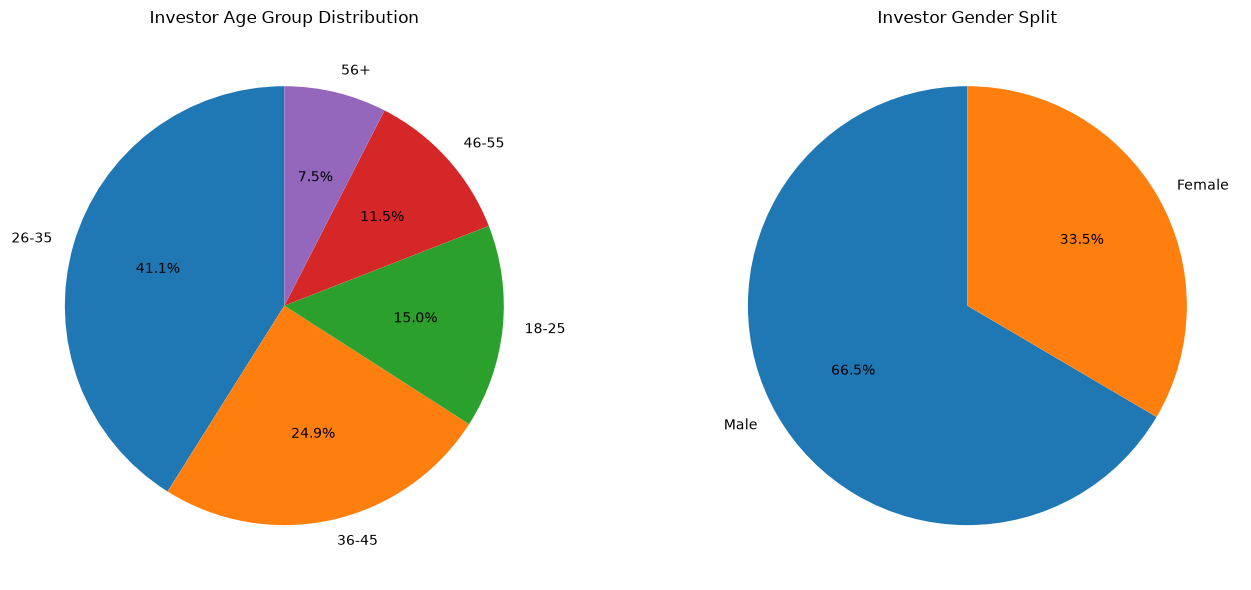

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

 gender
Male      21809
Female    10969
Name: count, dtype: int64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

age_counts = txns_full["age_group"].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Investor Age Group Distribution")

gender_counts = txns_full["gender"].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Investor Gender Split")

plt.tight_layout()
plt.savefig("../investor_demographics.png", dpi=150)
plt.show()

print(age_counts)
print("\n", gender_counts)

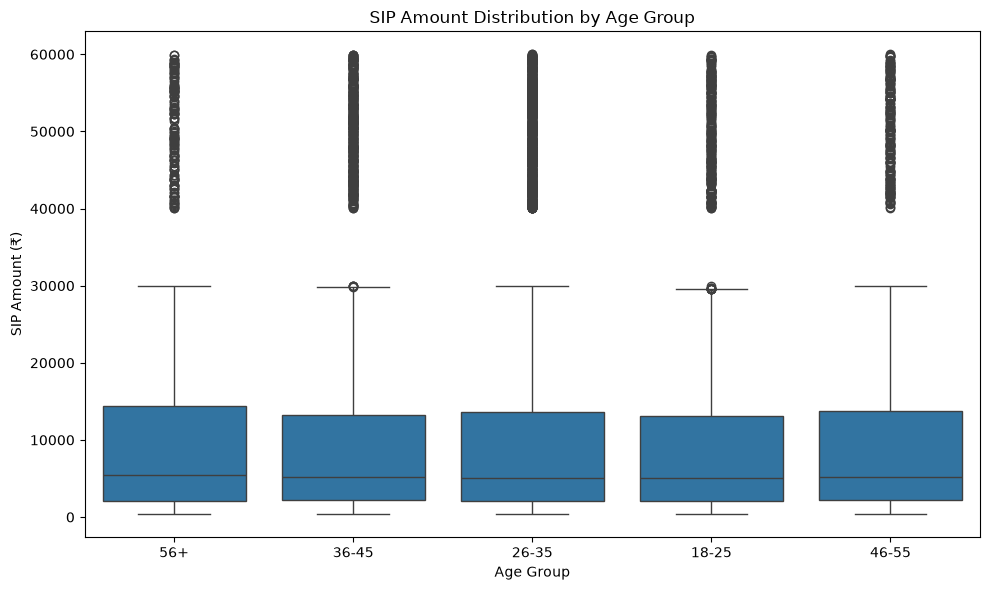

In [11]:
sip_txns = txns_full[txns_full["transaction_type"] == "SIP"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=sip_txns, x="age_group", y="amount_inr")
plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")
plt.tight_layout()
plt.savefig("../sip_amount_by_age_group.png", dpi=150)
plt.show()

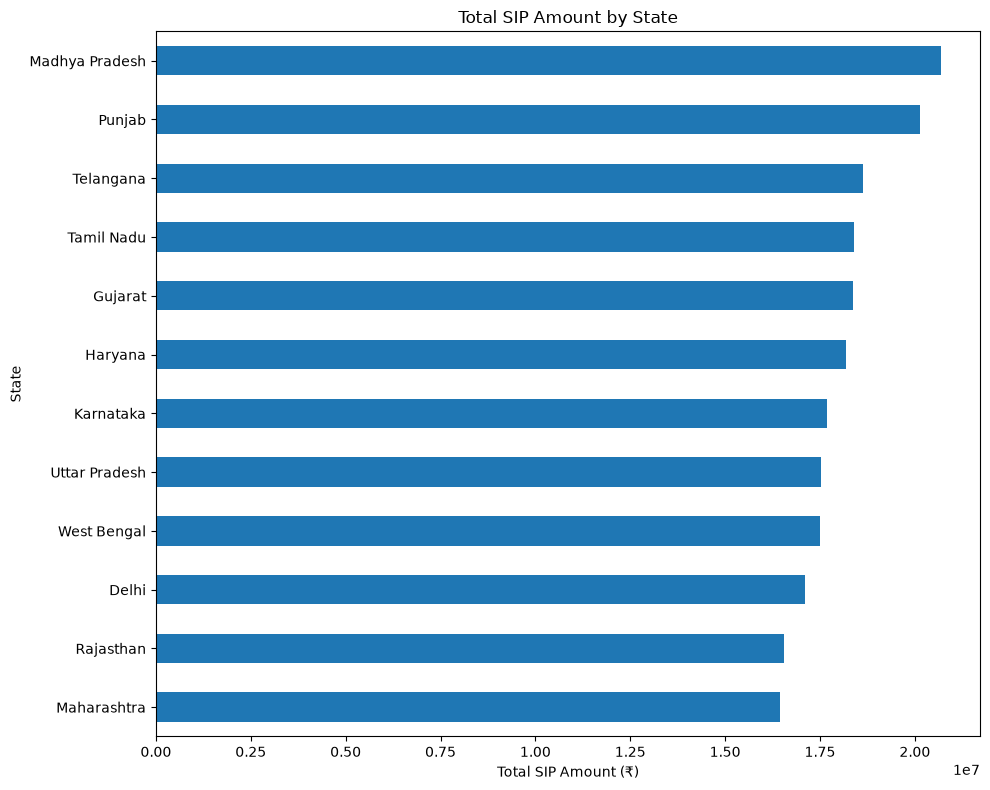

<StringArray>
['T30', 'B30']
Length: 2, dtype: str


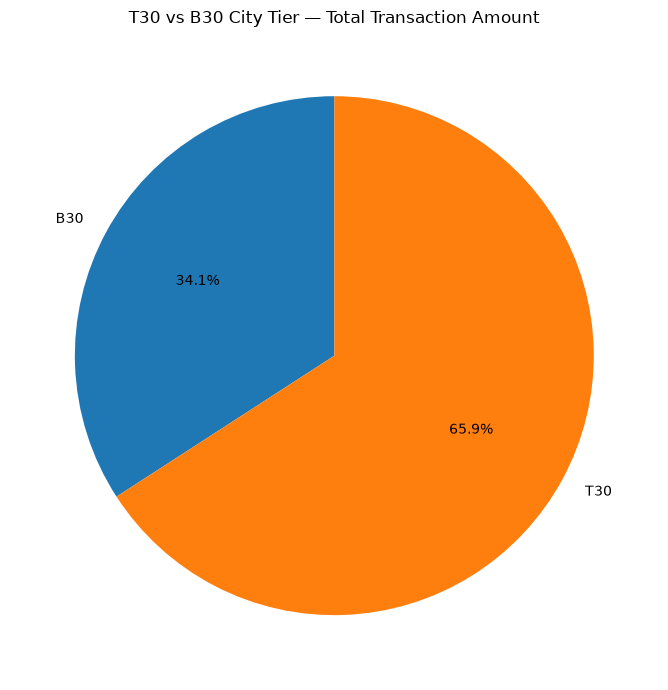

In [12]:
sip_by_state = txns_full[txns_full["transaction_type"] == "SIP"].groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10, 8))
sip_by_state.plot(kind="barh")
plt.title("Total SIP Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("../sip_amount_by_state.png", dpi=150)
plt.show()

# T30 vs B30 city tier split
print(txns_full["city_tier"].unique())
tier_counts = txns_full.groupby("city_tier")["amount_inr"].sum()

plt.figure(figsize=(7, 7))
plt.pie(tier_counts, labels=tier_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("T30 vs B30 City Tier — Total Transaction Amount")
plt.tight_layout()
plt.savefig("../t30_b30_split.png", dpi=150)
plt.show()

In [14]:
print(folio_count.columns.tolist())
folio_count.head()

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


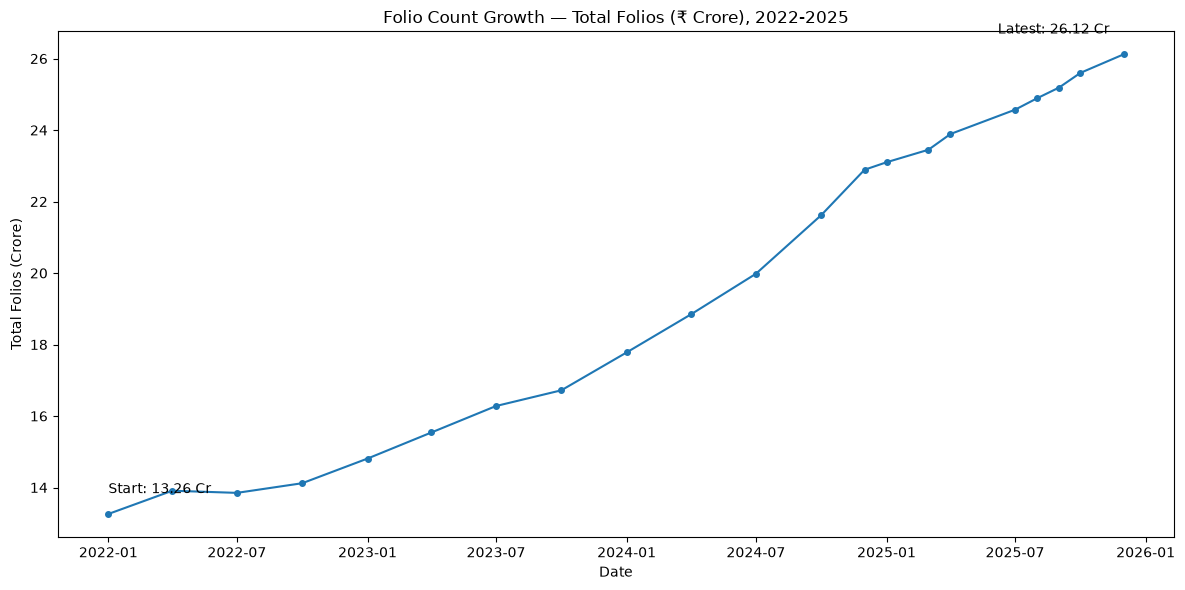

Start: 13.26 | End: 26.12


In [15]:
folio_count["month"] = pd.to_datetime(folio_count["month"])
folio_sorted = folio_count.sort_values("month")

plt.figure(figsize=(12, 6))
plt.plot(folio_sorted["month"], folio_sorted["total_folios_crore"], marker="o", markersize=4)

start_val = folio_sorted["total_folios_crore"].iloc[0]
end_val = folio_sorted["total_folios_crore"].iloc[-1]

plt.annotate(f"Start: {start_val} Cr", (folio_sorted["month"].iloc[0], start_val),
             textcoords="offset points", xytext=(0, 15), ha="left")
plt.annotate(f"Latest: {end_val} Cr", (folio_sorted["month"].iloc[-1], end_val),
             textcoords="offset points", xytext=(-10, 15), ha="right")

plt.title("Folio Count Growth — Total Folios (₹ Crore), 2022-2025")
plt.xlabel("Date")
plt.ylabel("Total Folios (Crore)")
plt.tight_layout()
plt.savefig("../folio_count_growth.png", dpi=150)
plt.show()

print("Start:", start_val, "| End:", end_val)

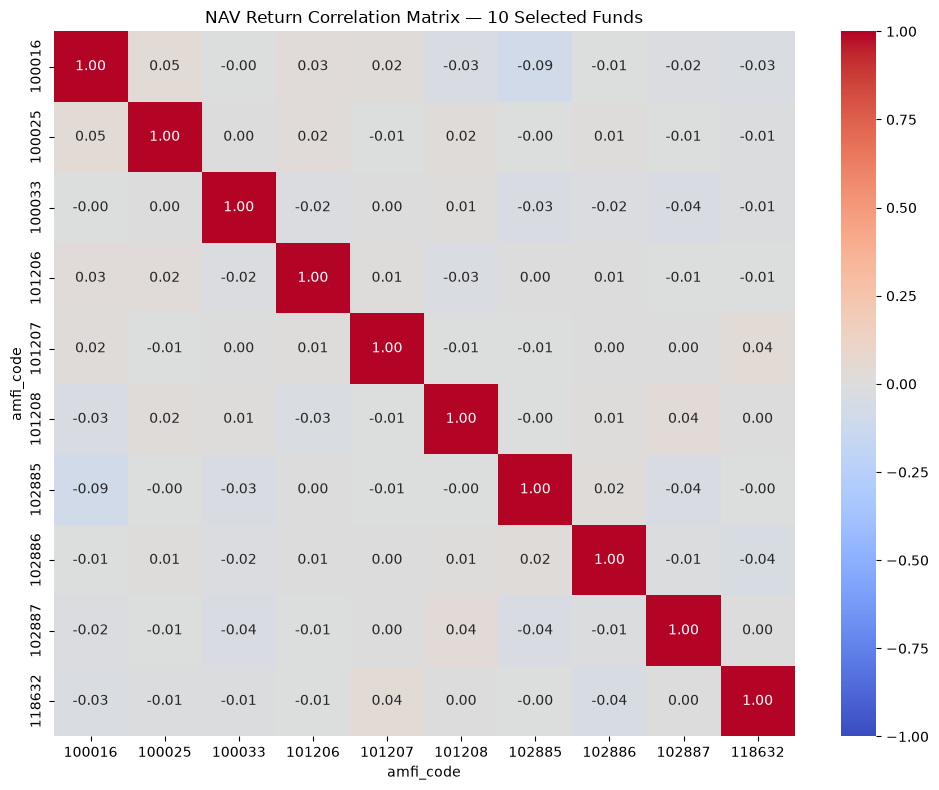

In [16]:
selected_codes = nav["amfi_code"].unique()[:10]
nav_selected = nav[nav["amfi_code"].isin(selected_codes)]

returns_pivot = nav_selected.pivot(index="date", columns="amfi_code", values="nav").pct_change()

corr_matrix = returns_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("NAV Return Correlation Matrix — 10 Selected Funds")
plt.tight_layout()
plt.savefig("../nav_return_correlation_matrix.png", dpi=150)
plt.show()

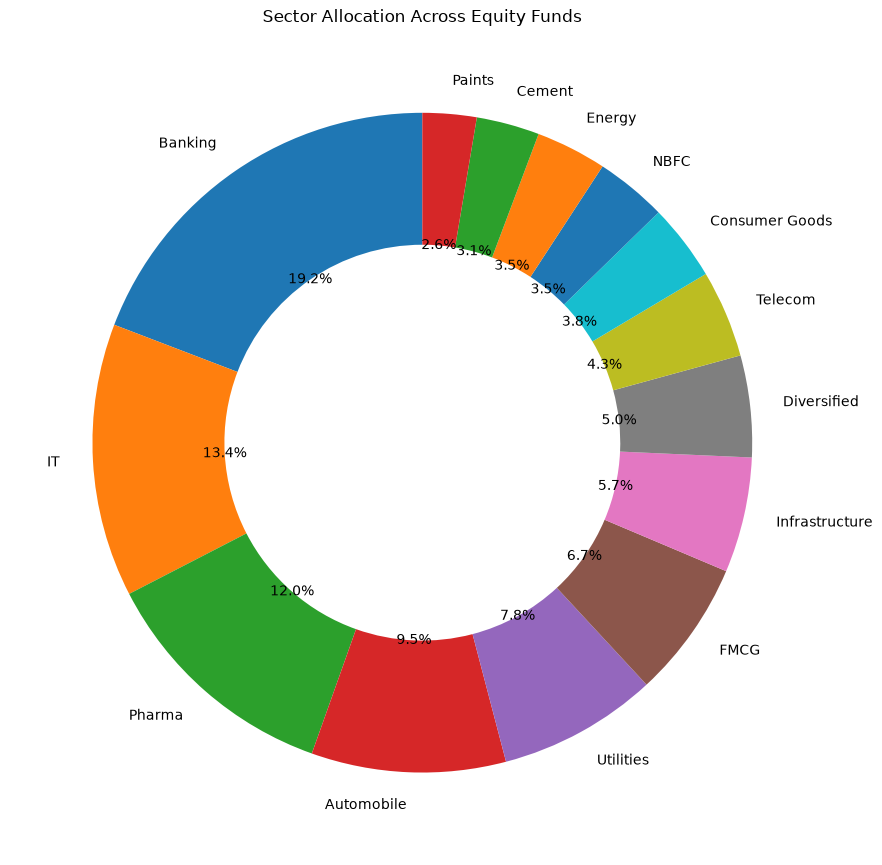

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


In [18]:
# Filter to equity funds only, using dim_fund's category
equity_codes = fund_master[fund_master["category"] == "Equity"]["amfi_code"]
equity_holdings = portfolio_holdings[portfolio_holdings["amfi_code"].isin(equity_codes)]

sector_weights = equity_holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 9))
plt.pie(sector_weights, labels=sector_weights.index, autopct="%1.1f%%", startangle=90,
        wedgeprops=dict(width=0.4))
plt.title("Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.savefig("../sector_allocation_donut.png", dpi=150)
plt.show()

print(sector_weights)

## Key EDA Findings

1. **Fund NAV scales vary dramatically across schemes** — one fund trades at a NAV in the thousands while most sit under 1,000, making single-scale comparison charts dominated by outliers; normalized/indexed views are more useful for trend comparison.

2. **SBI Mutual Fund is the clear AUM leader**, reaching ₹12.5 lakh crore by 2025 — nearly double the next closest fund house, and consistent across every year 2022-2025.

3. **SIP inflows have grown steadily and hit an all-time high of ₹31,002 Cr in December 2025**, showing sustained retail investor momentum with no major pullback across the 4-year window.

4. **Category-level inflows vary significantly by month and fund type** (see heatmap) — no single category dominates consistently, suggesting rotating investor preference across market cycles.

5. **The investor base skews toward the 26-35 age group (41.1%)**, with a roughly 2:1 male-to-female split (66.5% / 33.5%) — a demographic worth flagging for targeted outreach.

6. **SIP ticket sizes are broadly similar across age groups** (median ~₹10,000-12,000), though older age brackets (56+) show a wider spread of high-value outliers.

7. **T30 cities account for 65.9% of total transaction value**, versus 34.1% from B30 — confirming continued urban concentration of mutual fund investing despite India's broader financial inclusion push.

8. **Total folio count nearly doubled over the dataset's span**, from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), reflecting strong growth in overall investor participation.

9. **Fund returns show negligible correlation with each other** (all pairwise correlations between -0.09 and +0.05 across 10 sampled funds), consistent with the near-zero Alpha/Beta correlation against NIFTY100 found in the Day 3 performance analysis — suggesting the underlying NAV series were likely generated independently rather than reflecting shared market-driven co-movement.

10. **Equity fund portfolios are heavily concentrated in Banking (19.2%) and IT (13.4%)**, together accounting for nearly a third of total sector allocation, with the remaining weight spread across 13 other sectors.